# TRPO and PPO — Trust Region Policy Optimisation

- Schulman et al., **"Trust Region Policy Optimization"**, *ICML* 2015.
- Schulman et al., **"Proximal Policy Optimization Algorithms"**, *arXiv* 2017.

Both algorithms address the same problem: how large a policy update step is safe?
TRPO solves it with a constrained optimisation (hard KL bound).  
PPO approximates it with a clipped surrogate objective (simple SGD).

**Environment:** CartPole-v1.  **Runtime:** ≈ 5–8 min on CPU.

## Outline

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Background | The step-size problem in vanilla PG |
| 2 | Performance Difference Lemma | Exact identity for policy improvement; foundation of TRPO & PPO |
| 3 | TRPO Theory | Surrogate objective + KL trust-region constraint |
| 4 | TRPO Implementation | Conjugate gradient, Fisher-vector product, line search |
| 5 | From TRPO to PPO | Replacing the constraint with a clipped objective |
| 6 | GAE | Generalized Advantage Estimation (λ-returns) |
| 7 | PPO Agent | Full PPO-Clip implementation |
| 8 | Training & Results | TRPO vs PPO on CartPole |
| 9 | Ablations | Clip ε, GAE λ, entropy bonus, value clipping |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import copy
import gymnasium as gym
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  gymnasium {gym.__version__}  |  device: {device}')

def smooth(x, w=20):
    if w <= 1 or len(x) < w: return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode='valid')

PyTorch 2.4.1  |  gymnasium 1.2.3  |  device: cpu


---
## 1 — Background: The Step-Size Problem

### REINFORCE (vanilla policy gradient)
$$\theta \leftarrow \theta + \alpha \sum_t \nabla_\theta \log \pi_\theta(a_t|s_t)\, G_t$$

Policy gradient has a **fundamental step-size problem**:
- Too **small** $\alpha$ → slow learning
- Too **large** $\alpha$ → policy collapses irreversibly

Unlike supervised learning, a bad update in RL changes the data distribution.  
A policy that takes random actions collects bad data → future gradients point in random directions → recovery is very slow or impossible.

### Why is it worse than supervised learning?

In supervised learning, the data is fixed; a bad gradient step can be recovered from by taking a good step next iteration.  
In RL, the data comes from the *current policy*. A collapsed policy collects bad experience, producing bad gradient estimates, causing further collapse — a **destructive feedback loop**.

### The key insight (Kakade & Langford, 2002)
Policy improvement is guaranteed if the new policy is not too far from the old one in terms of **KL divergence**:
$$\eta(\tilde{\pi}) \ge L_{\pi}(\tilde{\pi}) - \frac{4\epsilon\gamma}{(1-\gamma)^2} \max_s D_{\mathrm{KL}}(\pi \| \tilde{\pi})[s]$$
where $L_\pi$ is the surrogate objective and $\eta$ is the true expected return.

REINFORCE lr=0.0001 ...
REINFORCE lr=0.001 ...
REINFORCE lr=0.005 ...
REINFORCE lr=0.01 ...


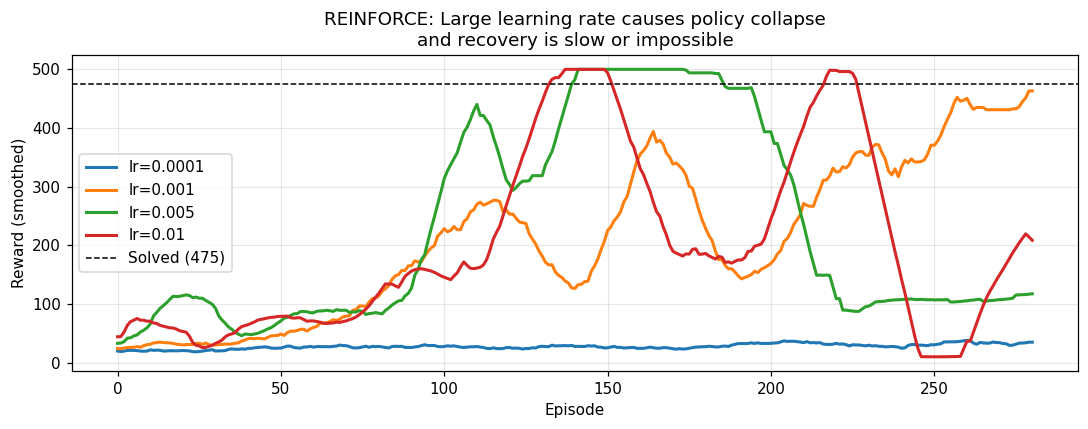

In [2]:
# ── Demo: large learning rate destroys the policy ────────────────────────────
# Vanilla REINFORCE on CartPole with different learning rates

class PolicyNet(nn.Module):
    def __init__(self, state_dim=4, n_actions=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),    nn.Tanh(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x): return F.softmax(self.net(x), dim=-1)

def reinforce(lr, n_episodes=300, seed=0, gamma=0.99):
    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make('CartPole-v1')
    policy = PolicyNet()
    opt = optim.Adam(policy.parameters(), lr=lr)
    rewards_hist = []
    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed + ep)
        log_probs, rews = [], []
        done = False
        while not done:
            probs = policy(torch.FloatTensor(s))
            dist = Categorical(probs)
            a = dist.sample()
            s, r, term, trunc, _ = env.step(a.item())
            done = term or trunc
            log_probs.append(dist.log_prob(a))
            rews.append(r)
        # Monte Carlo returns
        G, returns = 0, []
        for r in reversed(rews):
            G = r + gamma * G; returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        loss = -torch.stack(log_probs).dot(returns)
        opt.zero_grad(); loss.backward(); opt.step()
        rewards_hist.append(sum(rews))
    env.close()
    return rewards_hist

lrs = [1e-4, 1e-3, 5e-3, 1e-2]
pg_results = {}
for lr in lrs:
    print(f'REINFORCE lr={lr} ...')
    pg_results[lr] = reinforce(lr)

fig, ax = plt.subplots(figsize=(10, 4))
for lr, r in pg_results.items():
    ax.plot(smooth(r, 20), lw=2, label=f'lr={lr}')
ax.axhline(475, color='k', lw=1, linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (smoothed)')
ax.set_title('REINFORCE: Large learning rate causes policy collapse\n'
             'and recovery is slow or impossible')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 2 — Performance Difference Lemma

The **Performance Difference Lemma** (PDL; Kakade & Langford 2002, restated in Schulman et al. 2015) is the mathematical bedrock on which both TRPO and PPO are built. It gives an *exact* expression for how much a new policy $\tilde\pi$ improves over the current policy $\pi$.

---

### Setup

Define the **value and advantage functions** under $\pi$:

$$V^\pi(s) = \mathbb{E}_{\tau \sim \pi}\!\left[\sum_{t=0}^\infty \gamma^t r(s_t,a_t) \;\middle|\; s_0=s\right], \qquad A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)$$

Define the **discounted state visitation distribution** under policy $\tilde\pi$:

$$d^{\tilde\pi}(s) = (1-\gamma)\sum_{t=0}^\infty \gamma^t \Pr(s_t=s \mid \tilde\pi, s_0 \sim \mu)$$

where $\mu$ is the initial-state distribution and $\eta(\pi) = \mathbb{E}_{s_0\sim\mu}[V^\pi(s_0)]$ is the true expected return.

---

### Statement (PDL)

$$\boxed{\eta(\tilde\pi) - \eta(\pi) = \frac{1}{1-\gamma}\,\mathbb{E}_{s \sim d^{\tilde\pi},\; a \sim \tilde\pi(\cdot|s)}\!\bigl[A^\pi(s,a)\bigr]}$$

---

### Derivation

**Step 1 — Telescoping identity.**  For any trajectory $\tau=(s_0,a_0,s_1,a_1,\ldots)$ rolled out under $\tilde\pi$:

$$\sum_{t=0}^\infty \gamma^t A^\pi(s_t,a_t) = \sum_{t=0}^\infty \gamma^t \bigl[r(s_t,a_t) + \gamma V^\pi(s_{t+1}) - V^\pi(s_t)\bigr]$$

because $A^\pi(s,a) = r(s,a) + \gamma\mathbb{E}_{s'}[V^\pi(s')] - V^\pi(s)$ by Bellman.

**Step 2 — Take the expectation under $\tilde\pi$.**

$$\mathbb{E}_{\tau\sim\tilde\pi}\!\left[\sum_{t=0}^\infty \gamma^t A^\pi(s_t,a_t)\right]
= \mathbb{E}_{\tau\sim\tilde\pi}\!\left[\sum_{t=0}^\infty \gamma^t r(s_t,a_t)\right]
+ \mathbb{E}_{\tau\sim\tilde\pi}\!\left[\sum_{t=0}^\infty \bigl(\gamma^{t+1}V^\pi(s_{t+1}) - \gamma^t V^\pi(s_t)\bigr)\right]$$

**Step 3 — Evaluate the telescoping sum.**  The second term telescopes:

$$\sum_{t=0}^\infty \bigl(\gamma^{t+1}V^\pi(s_{t+1}) - \gamma^t V^\pi(s_t)\bigr) = -V^\pi(s_0) + \lim_{T\to\infty}\gamma^T V^\pi(s_T) = -V^\pi(s_0)$$

(assuming bounded rewards so $\gamma^T V^\pi(s_T)\to 0$).  Therefore:

$$\mathbb{E}_{\tau\sim\tilde\pi}\!\left[\sum_{t=0}^\infty \gamma^t A^\pi(s_t,a_t)\right] = \eta(\tilde\pi) - \eta(\pi)$$

**Step 4 — Marginalise over states.**  Writing $\mathbb{E}_{\tau\sim\tilde\pi}[\cdots]$ as an expectation over the discounted state marginal $d^{\tilde\pi}$:

$$\eta(\tilde\pi) - \eta(\pi) = \frac{1}{1-\gamma}\,\mathbb{E}_{s\sim d^{\tilde\pi}}\mathbb{E}_{a\sim\tilde\pi(\cdot|s)}\bigl[A^\pi(s,a)\bigr] \qquad \square$$

---

### The fundamental obstacle

The right-hand side involves $d^{\tilde\pi}$ — the state distribution of the *new* policy we are searching for.  We cannot sample from $d^{\tilde\pi}$ without already having $\tilde\pi$, creating a **chicken-and-egg** problem that prevents direct optimisation.

---

### Local surrogate objective

**Key approximation:** replace $d^{\tilde\pi} \approx d^\pi$ (use the *old* policy's state distribution).  This is justified when $\tilde\pi \approx \pi$, because the state distributions differ by $O\!\bigl(\max_s D_\mathrm{TV}(\pi(\cdot|s)\,\|\,\tilde\pi(\cdot|s))\bigr)$.

Using **importance sampling** to handle $a\sim\tilde\pi$ vs $a\sim\pi$:

$$L_\pi(\tilde\pi) \;=\; \frac{1}{1-\gamma}\,\mathbb{E}_{s\sim d^\pi,\,a\sim\pi}\!\left[\frac{\tilde\pi(a|s)}{\pi(a|s)}\,A^\pi(s,a)\right]
\;=\; \mathbb{E}_{s\sim d^\pi,\,a\sim\pi}\!\bigl[r_t(\tilde\pi)\,A^\pi(s,a)\bigr]$$

where $r_t(\tilde\pi)=\tilde\pi(a|s)/\pi(a|s)$ is the **importance ratio**.  Note $L_\pi(\pi)=\eta(\pi)$ and $\nabla_{\tilde\pi}L_\pi|_{\tilde\pi=\pi}=\nabla_{\tilde\pi}\eta|_{\tilde\pi=\pi}$, so $L_\pi$ is a first-order local approximation.

---

### Conservative policy iteration bound

Kakade & Langford proved that the approximation error is bounded by the policy divergence:

$$\eta(\tilde\pi) \;\ge\; L_\pi(\tilde\pi) - \frac{4\epsilon\gamma}{(1-\gamma)^2}\,\max_s D_\mathrm{KL}(\pi\,\|\,\tilde\pi)[s], \qquad \epsilon = \max_{s,a}|A^\pi(s,a)|$$

Maximising $L_\pi$ while keeping the KL below the penalty term therefore **guarantees monotone improvement** $\eta(\tilde\pi)\ge\eta(\pi)$.

---

### How TRPO builds on the PDL

| Design choice | Motivation from PDL |
|---------------|---------------------|
| Optimise $L_\pi$ (surrogate) instead of $\eta$ | $d^{\tilde\pi}$ is intractable; $d^\pi$ is the rollout we already have |
| Replace $\max_s\,\mathrm{KL}$ bound → $\mathbb{E}_s[\mathrm{KL}]$ constraint | Mean KL is tighter empirically and avoids worst-case pessimism |
| Hard KL trust-region: $\mathbb{E}_s[D_\mathrm{KL}]\le\delta$ | Keeps surrogate valid as a proxy for $\eta$ → guaranteed improvement |
| Conjugate gradient + line search | Enforces the constraint exactly without forming the Fisher matrix |

$$\max_\theta\; L_\pi(\pi_\theta) \quad\text{s.t.}\quad \mathbb{E}_s\bigl[D_\mathrm{KL}(\pi_{\theta_\mathrm{old}}\,\|\,\pi_\theta)\bigr]\le\delta$$

### How PPO builds on the PDL

PPO retains the same surrogate $L_\pi$ but replaces the hard KL constraint with a **clipped ratio** that implicitly limits how far $\tilde\pi$ can stray from $\pi$:

$$L^\mathrm{CLIP}(\theta) = \mathbb{E}_t\!\left[\min\!\bigl(r_t\,A_t,\;\mathrm{clip}(r_t,1{-}\varepsilon,1{+}\varepsilon)\,A_t\bigr)\right]$$

The $\min$ makes this a **pessimistic lower bound** on the true surrogate:
- If $A_t>0$: gain is capped when the ratio exceeds $1+\varepsilon$ (policy already over-weights this action)
- If $A_t<0$: penalty is capped when the ratio drops below $1-\varepsilon$ (policy already under-weights it)

This removes the expensive second-order solve of TRPO while preserving the monotone-improvement spirit of the PDL.

| | TRPO | PPO |
|--|------|-----|
| Surrogate objective | $L_\pi$ (IS-corrected) | $L^\mathrm{CLIP}$ (clipped IS) |
| Trust-region enforcement | Hard KL constraint (conjugate gradient) | Implicit via ratio clipping |
| Optimiser | Natural gradient + line search | Adam / SGD |
| Sample reuse | Single update per rollout | Multiple epochs per rollout |

---
## 3 — TRPO: Theory

### Surrogate objective with importance sampling

We want to optimise the true policy performance $\eta(\pi_\theta)$, but can only sample from
the *old* policy $\pi_{\theta_{\text{old}}}$. The **surrogate objective** corrects for this via
importance sampling:

$$L(\theta) = \mathbb{E}_{s,a \sim \pi_{\theta_{\text{old}}}}\!\left[
    \underbrace{\frac{\pi_\theta(a|s)}{\pi_{\theta_{\text{old}}}(a|s)}}_{r_t(\theta)\;\text{(ratio)}} A^{\pi_{\theta_{\text{old}}}}(s,a)
\right]$$

$L$ is a **first-order** approximation of $\eta$ that is valid only near $\theta_{\text{old}}$ — exactly as the PDL analysis showed.

### The trust region constraint

TRPO maximises $L(\theta)$ subject to a hard KL constraint:

$$\max_\theta\ L(\theta) \quad \text{s.t.}\quad \mathbb{E}_s\bigl[D_{\mathrm{KL}}(\pi_{\theta_{\text{old}}}(\cdot|s)\,\|\,\pi_\theta(\cdot|s))\bigr] \le \delta$$

Typical value: $\delta = 0.01$.  This defines a **trust region** — the set of policies where
$L$ is a reliable proxy for $\eta$.

### Solution via natural gradient

Near the constraint boundary, the update is:
$$\theta \leftarrow \theta_{\text{old}} + \sqrt{\frac{2\delta}{g^T F^{-1} g}}\, F^{-1} g$$

where $g = \nabla_\theta L$ and $F$ is the **Fisher Information Matrix** (Hessian of KL w.r.t. $\theta$).

$F^{-1}g$ is the **natural gradient** — the steepest ascent direction in distribution space.  
Computing $F^{-1}g$ directly requires $O(|\theta|^2)$ memory.  
TRPO uses the **conjugate gradient** algorithm to compute $F^{-1}g$ in $O(|\theta|)$ using only matrix-vector products.

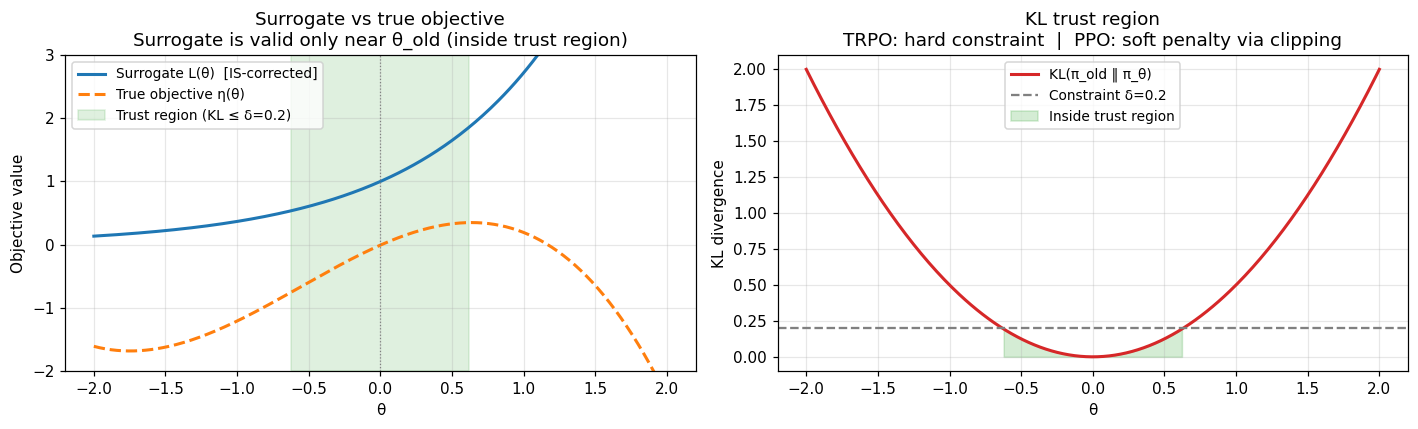

In [3]:
# ── Visualise surrogate objective and KL trust region ────────────────────────
theta = np.linspace(-2, 2, 300)

# Synthetic: old policy param = 0, advantage = +1
# ratio r(θ) = exp(θ - θ_old) for a Gaussian (simplified)
theta_old = 0.0
A = 1.0  # positive advantage

# Surrogate L(θ) = r(θ) * A  where r = exp(θ - θ_old) / exp(0) simplified
ratio = np.exp(theta - theta_old)
surrogate = ratio * A

# True objective (quadratic approx)
true_obj = theta - 0.5 * theta**2 - 0.3 * theta**3  # synthetic
true_obj = true_obj - true_obj[len(theta)//2]  # zero at theta_old

# KL divergence (Gaussian: KL = 0.5 * (θ - θ_old)^2)
kl = 0.5 * (theta - theta_old)**2
delta = 0.2
in_region = kl <= delta

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(theta, surrogate, lw=2, label='Surrogate L(θ)  [IS-corrected]')
ax.plot(theta, true_obj,  lw=2, label='True objective η(θ)', linestyle='--')
ax.axvline(0, color='gray', lw=0.8, linestyle=':')
ax.fill_between(theta, -2, 3, where=in_region, alpha=0.15, color='C2',
                label=f'Trust region (KL ≤ δ={delta})')
ax.set_ylim(-2, 3)
ax.set_xlabel('θ'); ax.set_ylabel('Objective value')
ax.set_title('Surrogate vs true objective\n'
             'Surrogate is valid only near θ_old (inside trust region)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta, kl, lw=2, color='C3', label='KL(π_old ‖ π_θ)')
ax.axhline(delta, color='gray', lw=1.5, linestyle='--', label=f'Constraint δ={delta}')
ax.fill_between(theta, 0, kl, where=in_region, alpha=0.2, color='C2', label='Inside trust region')
ax.set_xlabel('θ'); ax.set_ylabel('KL divergence')
ax.set_title('KL trust region\n'
             'TRPO: hard constraint  |  PPO: soft penalty via clipping')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 4 — TRPO: Implementation

### Three components

**1. Fisher-vector product** (Pearlmutter trick)  
Computing $Fv$ without forming $F$ explicitly:
$$Fv = \nabla_\theta \bigl[(\nabla_\theta D_{\mathrm{KL}})^T v\bigr]$$
Cost: two backward passes. Avoids the $O(|\theta|^2)$ Fisher matrix.

**2. Conjugate gradient**  
Solve $Fx = g$ iteratively using only $Fv$ products. Returns $x^* = F^{-1}g$ in ~10 steps.

**3. Backtracking line search**  
The full natural gradient step $x^*$ may violate the KL constraint due to approximation error.
Try $\alpha^k \cdot x^*$ for $k=0,1,2,\ldots$ until KL $\le\delta$ and $L$ improves.

### Update rule
```
g   ← ∇_θ L(θ_old)                         ← policy gradient
x*  ← CG(F, g)                              ← natural gradient direction
β   ← sqrt(2δ / (x*ᵀ F x*))               ← step size
θ   ← θ_old + line_search(β · x*)          ← backtracking
V   ← update value function (separate SGD)
```

In [4]:
# ── Shared network and utilities ─────────────────────────────────────────────

class ActorCritic(nn.Module):
    """Shared-backbone actor-critic network (tanh activations, as in TRPO/PPO papers)."""
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),    nn.Tanh(),
        )
        self.actor  = nn.Linear(hidden, n_actions)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return F.softmax(self.actor(h), dim=-1), self.critic(h).squeeze(-1)

    def act(self, state):
        """Sample action; return (action, log_prob, entropy, value)."""
        probs, value = self(state)
        dist = Categorical(probs)
        a = dist.sample()
        return a, dist.log_prob(a), dist.entropy(), value

    def evaluate(self, states, actions):
        """Re-evaluate stored actions under current policy."""
        probs, values = self(states)
        dist = Categorical(probs)
        return dist.log_prob(actions), dist.entropy(), values


def get_flat_params(params):
    """Concatenate parameter data from a list of Parameters into a 1-D tensor."""
    return torch.cat([p.data.view(-1) for p in params])

def set_flat_params(params, flat_params):
    """Copy a 1-D flat tensor back into a list of Parameters (in-place)."""
    idx = 0
    for p in params:
        n = p.numel()
        p.data.copy_(flat_params[idx:idx+n].view(p.shape))
        idx += n

def flat_grad(loss, params, create_graph=False, retain_graph=False):
    grads = torch.autograd.grad(loss, params, create_graph=create_graph,
                                 retain_graph=retain_graph, allow_unused=True)
    return torch.cat([g.contiguous().view(-1) if g is not None
                      else torch.zeros_like(p).view(-1)
                      for g, p in zip(grads, params)])


def conjugate_gradient(hvp_fn, b, n_steps=10, tol=1e-10):
    """
    Solve Ax = b iteratively via conjugate gradient, where A = F (Fisher IM).
    Only requires matrix-vector products Av — never forms A explicitly.
    """
    x = torch.zeros_like(b)
    r, p = b.clone(), b.clone()
    rTr = r.dot(r)
    for _ in range(n_steps):
        Ap    = hvp_fn(p)
        alpha = rTr / (p.dot(Ap) + 1e-8)
        x     = x + alpha * p
        r     = r - alpha * Ap
        new_rTr = r.dot(r)
        if new_rTr < tol:
            break
        p   = r + (new_rTr / rTr) * p
        rTr = new_rTr
    return x


print('ActorCritic, flat_grad, conjugate_gradient defined.')

# Verify CG on a known system: A = [[4,1],[1,3]], b = [1,2] → x = [1/11, 7/11]
A = torch.tensor([[4.,1.],[1.,3.]])
b = torch.tensor([1.,2.])
x = conjugate_gradient(lambda v: A @ v, b, n_steps=20)
print(f'CG sanity check: Ax = {(A@x).numpy()}  (should be [1, 2])')

ActorCritic, flat_grad, conjugate_gradient defined.
CG sanity check: Ax = [1. 2.]  (should be [1, 2])


In [5]:
def compute_gae(rewards, values, dones, last_value=0.0, gamma=0.99, lam=0.95):
    """
    Generalized Advantage Estimation (Schulman et al. 2016).
    δ_t = r_t + γ V(s_{t+1}) − V(s_t)
    A_t = Σ_{l≥0} (γλ)^l δ_{t+l}
    Returns (advantages, discounted returns).
    """
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    gae = 0.0
    for t in reversed(range(T)):
        next_val = last_value if t == T - 1 else values[t+1]
        delta = rewards[t] + gamma * next_val * (1 - dones[t]) - values[t]
        gae   = delta + gamma * lam * (1 - dones[t]) * gae
        advantages[t] = gae
    returns = advantages + np.array(values, dtype=np.float32)
    return advantages, returns


class RolloutBuffer:
    """On-policy rollout storage."""
    def __init__(self):
        self.states, self.actions, self.rewards = [], [], []
        self.log_probs, self.values, self.dones  = [], [], []

    def add(self, s, a, r, lp, v, d):
        self.states.append(s); self.actions.append(a)
        self.rewards.append(r); self.log_probs.append(lp)
        self.values.append(v); self.dones.append(d)

    def get_tensors(self, gamma=0.99, lam=0.95):
        advs, rets = compute_gae(self.rewards, self.values, self.dones,
                                  gamma=gamma, lam=lam)
        return {
            'states':    torch.FloatTensor(np.array(self.states)),
            'actions':   torch.LongTensor(self.actions),
            'log_probs': torch.FloatTensor(self.log_probs),
            'values':    torch.FloatTensor(self.values),
            'advs':      torch.FloatTensor(advs),
            'returns':   torch.FloatTensor(rets),
        }

    def clear(self): self.__init__()


def collect_rollout(net, env_name, n_steps=2048, seed=0, gamma=0.99, lam=0.95):
    """Run current policy for n_steps; return batched data with GAE."""
    env = gym.make(env_name)
    buf = RolloutBuffer()
    ep_rewards, current_ep = [], 0.0
    s, _ = env.reset(seed=seed)
    for _ in range(n_steps):
        with torch.no_grad():
            st = torch.FloatTensor(s)
            a, lp, _, v = net.act(st)
        ns, r, term, trunc, _ = env.step(a.item())
        done = term or trunc
        buf.add(s, a.item(), r, lp.item(), v.item(), float(done))
        current_ep += r
        s = ns
        if done:
            ep_rewards.append(current_ep); current_ep = 0.0
            s, _ = env.reset()
    env.close()
    data = buf.get_tensors(gamma=gamma, lam=lam)
    return data, ep_rewards


print('GAE, RolloutBuffer, collect_rollout defined.')

GAE, RolloutBuffer, collect_rollout defined.


In [6]:
class TRPOAgent:
    """
    Trust Region Policy Optimization (Schulman et al. 2015).

    Actor update: constrained optimisation via natural gradient + CG + line search.
    Critic update: multiple epochs of MSE regression.
    """
    def __init__(self, state_dim, n_actions,
                 gamma=0.99, lam=0.95,
                 max_kl=0.01,       # trust region size δ
                 damping=0.1,       # Tikhonov damping for Fisher matrix
                 cg_steps=10,       # conjugate gradient iterations
                 ls_steps=10,       # line search backtracking steps
                 ls_ratio=0.5,      # line search shrink factor
                 vf_lr=1e-3,
                 vf_epochs=5,
                 n_steps=2048):
        self.net       = ActorCritic(state_dim, n_actions).to(device)
        self.vf_opt    = optim.Adam(self.net.critic.parameters(), lr=vf_lr)
        self.gamma     = gamma; self.lam = lam
        self.max_kl    = max_kl; self.damping  = damping
        self.cg_steps  = cg_steps; self.ls_steps = ls_steps
        self.ls_ratio  = ls_ratio
        self.vf_epochs = vf_epochs; self.n_steps = n_steps

    def _actor_params(self):
        return list(self.net.shared.parameters()) + list(self.net.actor.parameters())

    def _surrogate(self, states, actions, old_log_probs, advantages):
        log_probs, _, _ = self.net.evaluate(states, actions)
        ratios = torch.exp(log_probs - old_log_probs)
        return (ratios * advantages).mean()

    def _kl(self, states, old_probs):
        """KL(π_old ‖ π_current) averaged over states."""
        probs, _ = self.net(states)
        return (old_probs * (old_probs.clamp(1e-8).log() - probs.clamp(1e-8).log())).sum(-1).mean()

    def _fisher_vector_product(self, states, old_probs, vector):
        """Fv via Pearlmutter trick: ∇(∇KL · v) + damping·v"""
        kl = self._kl(states, old_probs)
        params = self._actor_params()
        grads  = flat_grad(kl, params, create_graph=True)
        gv     = grads.dot(vector)
        hvp    = flat_grad(gv, params, retain_graph=False)
        return hvp.detach() + self.damping * vector

    def update(self, data):
        states      = data['states'].to(device)
        actions     = data['actions'].to(device)
        old_log_probs = data['log_probs'].to(device)
        advs        = data['advs'].to(device)
        returns     = data['returns'].to(device)

        # Normalise advantages
        advs = (advs - advs.mean()) / (advs.std() + 1e-8)

        # ── Actor update via natural gradient + CG + line search ────────────────
        params = self._actor_params()
        with torch.no_grad():
            old_probs, _ = self.net(states)
            old_probs = old_probs.detach()

        # Policy gradient g
        L = self._surrogate(states, actions, old_log_probs, advs)
        g = flat_grad(L, params, retain_graph=False)

        # Natural gradient x* = F^{-1} g via CG
        hvp_fn = lambda v: self._fisher_vector_product(states, old_probs, v)
        x_star = conjugate_gradient(hvp_fn, g.detach(), n_steps=self.cg_steps)

        # Full step size: β = sqrt(2δ / (x*ᵀ F x*))
        xFx  = x_star.dot(hvp_fn(x_star))
        beta = torch.sqrt(2 * self.max_kl / (xFx + 1e-8))
        full_step = (beta * x_star).detach()

        # Backtracking line search: shrink step until KL ≤ δ and L improves
        # Use only actor params for get/set (critic is updated separately below)
        old_params = get_flat_params(params)
        with torch.no_grad():
            L_old = self._surrogate(states, actions, old_log_probs, advs).item()
        accept = False
        kl_new = 0.0; L_new = L_old
        for k in range(self.ls_steps):
            step = (self.ls_ratio ** k) * full_step
            set_flat_params(params, old_params + step)
            with torch.no_grad():
                kl_new = self._kl(states, old_probs).item()
                L_new  = self._surrogate(states, actions, old_log_probs, advs).item()
            if kl_new <= self.max_kl and L_new > L_old:
                accept = True; break
        if not accept:                   # revert if no good step found
            set_flat_params(params, old_params)

        # ── Critic update (standard MSE regression, multiple epochs) ────────────
        for _ in range(self.vf_epochs):
            self.net.zero_grad()
            _, _, values = self.net.evaluate(states, actions)
            vf_loss = F.mse_loss(values, returns)
            vf_loss.backward()
            self.vf_opt.step()

        return {'kl': kl_new if accept else 0.0,
                'accept': accept, 'L': L_new if accept else L_old}


print('TRPOAgent defined.')

TRPOAgent defined.


---
## 5 — From TRPO to PPO

### TRPO limitations
- Conjugate gradient requires many backward passes → slow per update
- Hard to implement correctly (many numerical edge cases)
- Incompatible with architectures that share parameters between actor and critic
- Cannot use mini-batches (CG must see the full batch)

### PPO: replace the constraint with a penalty

Instead of hard constraint, **clip** the probability ratio $r_t(\theta) = \pi_\theta(a|s)/\pi_{\theta_{\text{old}}}(a|s)$:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\!\left[\min\!\left(
    r_t(\theta)\,A_t,\;
    \underbrace{\mathrm{clip}(r_t(\theta),\,1-\varepsilon,\,1+\varepsilon)}_{\text{constrained ratio}}\,A_t
\right)\right]$$

The clip prevents $r_t$ from moving too far from 1 in either direction.  
The $\min$ ensures the objective is a **pessimistic** lower bound — we never benefit from a large ratio.

### Full PPO loss
$$L(\theta) = L^{\text{CLIP}}(\theta) - c_1\,L^{\text{VF}}(\theta) + c_2\,H[\pi_\theta]$$

| Term | Default | Purpose |
|------|---------|---------|
| $L^{\text{CLIP}}$ | — | Policy improvement inside trust region |
| $L^{\text{VF}} = (V_\theta - V_{\text{target}})^2$ | $c_1=0.5$ | Value function regression |
| $H[\pi_\theta]$ | $c_2=0.01$ | Entropy bonus — encourages exploration |

PPO trains for **multiple epochs** on the same rollout (e.g. 10 epochs, mini-batch size 64).

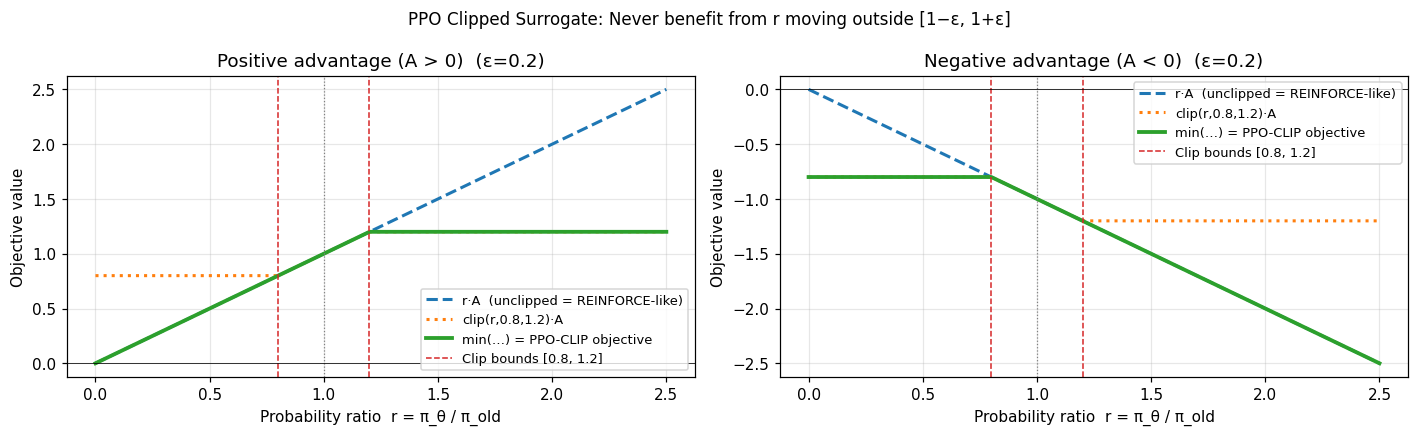

When A>0: clip prevents r>1+ε (don't increase π too much for good actions)
When A<0: clip prevents r<1-ε (don't decrease π too much for bad actions)


In [7]:
# ── Visualise the clipped surrogate ─────────────────────────────────────────
ratio = np.linspace(0, 2.5, 300)
eps   = 0.2
A_pos = 1.0   # positive advantage
A_neg = -1.0  # negative advantage

def ppo_clip(r, A, eps):
    return np.minimum(r * A, np.clip(r, 1-eps, 1+eps) * A)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, A, title in [
    (axes[0], A_pos, f'Positive advantage (A > 0)'),
    (axes[1], A_neg, f'Negative advantage (A < 0)'),
]:
    unclipped = ratio * A
    clipped   = np.clip(ratio, 1-eps, 1+eps) * A
    objective = ppo_clip(ratio, A, eps)

    ax.plot(ratio, unclipped, lw=2, label='r·A  (unclipped = REINFORCE-like)', linestyle='--')
    ax.plot(ratio, clipped,   lw=2, label=f'clip(r,{1-eps},{1+eps})·A', linestyle=':')
    ax.plot(ratio, objective, lw=2.5, label='min(…) = PPO-CLIP objective', color='C2')
    ax.axvline(1,     color='gray', lw=0.8, linestyle=':')
    ax.axvline(1-eps, color='C3',   lw=1,   linestyle='--', label=f'Clip bounds [{1-eps}, {1+eps}]')
    ax.axvline(1+eps, color='C3',   lw=1,   linestyle='--')
    ax.axhline(0,     color='k',    lw=0.5)
    ax.set_xlabel('Probability ratio  r = π_θ / π_old')
    ax.set_ylabel('Objective value')
    ax.set_title(title + f'  (ε={eps})')
    ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

fig.suptitle('PPO Clipped Surrogate: Never benefit from r moving outside [1−ε, 1+ε]', fontsize=11)
plt.tight_layout(); plt.show()

print('When A>0: clip prevents r>1+ε (don\'t increase π too much for good actions)')
print('When A<0: clip prevents r<1-ε (don\'t decrease π too much for bad actions)')

---
## 6 — GAE: Generalized Advantage Estimation

### The bias-variance trade-off in advantage estimation

| Estimator | Expression | Bias | Variance |
|-----------|-----------|------|----------|
| Monte Carlo (MC) | $G_t - V(s_t)$ | None | High |
| TD(0) | $r_t + \gamma V(s_{t+1}) - V(s_t)$ | High | Low |
| TD(λ) / GAE | $\sum_{l\ge0}(\gamma\lambda)^l\delta_{t+l}$ | Tunable | Tunable |

### GAE definition (Schulman et al. 2016)

Define the 1-step TD residual: $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$

$$A_t^{\text{GAE}(\gamma,\lambda)} = \sum_{l=0}^{\infty} (\gamma\lambda)^l\,\delta_{t+l}$$

- $\lambda = 0$: pure TD(0) — low variance, high bias
- $\lambda = 1$: Monte Carlo return minus baseline — unbiased, high variance
- $\lambda \in (0,1)$: interpolation — paper uses $\lambda = 0.95$

### Recursive computation (reverse scan, $O(T)$)
$$A_T = \delta_T, \qquad A_t = \delta_t + \gamma\lambda\,A_{t+1}$$

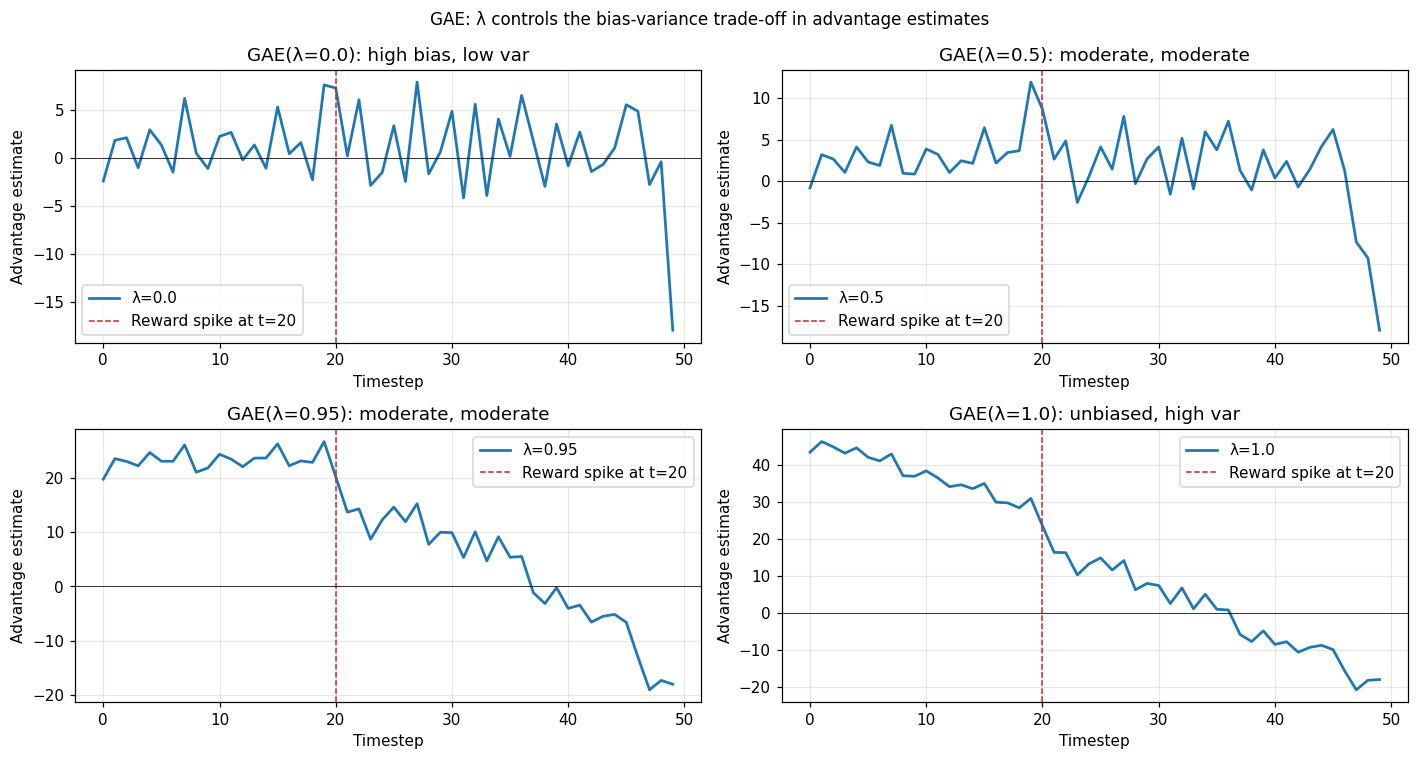

In [8]:
# ── Visualise GAE for different λ values ─────────────────────────────────────
np.random.seed(7)
T = 50
gamma = 0.99

# Synthetic episode: rewards and value estimates
rewards = np.ones(T)
rewards[20] = 10.0   # sparse reward spike
values  = np.linspace(0, 20, T) + np.random.randn(T) * 2
values  = np.clip(values, 0, None)
dones   = np.zeros(T); dones[-1] = 1.0

lambdas = [0.0, 0.5, 0.95, 1.0]
adv_estimates = {}
for lam in lambdas:
    advs, _ = compute_gae(rewards.tolist(), values.tolist(), dones.tolist(),
                           gamma=gamma, lam=lam)
    adv_estimates[lam] = advs

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=False)
for ax, lam in zip(axes.flat, lambdas):
    ax.plot(adv_estimates[lam], lw=1.8, color='C0', label=f'λ={lam}')
    ax.axvline(20, color='C3', lw=1, linestyle='--', label='Reward spike at t=20')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Timestep'); ax.set_ylabel('Advantage estimate')
    bias_str = 'high bias' if lam < 0.3 else ('unbiased' if lam == 1.0 else 'moderate')
    var_str  = 'low var'   if lam < 0.3 else ('high var'  if lam == 1.0 else 'moderate')
    ax.set_title(f'GAE(λ={lam}): {bias_str}, {var_str}')
    ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('GAE: λ controls the bias-variance trade-off in advantage estimates', fontsize=11)
plt.tight_layout(); plt.show()

---
## 7 — PPO Agent

### PPO-Clip Algorithm

```
FOR iteration = 1 … N:
  collect rollout of n_steps steps using π_θ_old
  compute GAE advantages  A_t^GAE
  compute returns  R_t = A_t + V(s_t)

  FOR epoch = 1 … K:                             ← K=10 in the paper
    FOR mini-batch b of size M from rollout:
      r_t = π_θ(a|s) / π_θ_old(a|s)             ← probability ratio

      L_CLIP = mean(min(r_t A_t, clip(r_t,1-ε,1+ε) A_t))
      L_VF   = mean((V_θ(s_t) − R_t)²)
      L_ENT  = mean(H[π_θ(·|s_t)])

      L = L_CLIP − c1·L_VF + c2·L_ENT
      θ ← θ + α·∇L

  θ_old ← θ
```

### Paper hyperparameters (Atari)

| Param | Value | Param | Value |
|-------|-------|-------|-------|
| Rollout length | 128 steps | Discount $\gamma$ | 0.99 |
| Epochs $K$ | 4 | GAE $\lambda$ | 0.95 |
| Mini-batch | 32×8 envs | Clip $\varepsilon$ | 0.1 |
| Entropy coef $c_2$ | 0.01 | VF coef $c_1$ | 1.0 |
| Learning rate | 2.5e-4 (linear decay) | Max grad norm | 0.5 |

In [9]:
class PPOAgent:
    """
    PPO-Clip (Schulman et al. 2017).
    All tricks are toggleable for ablation experiments.
    """
    def __init__(self, state_dim, n_actions,
                 lr=3e-4, gamma=0.99, lam=0.95,
                 # ── Trick 1: Clipped surrogate ──────────────────────────────
                 clip_eps=0.2,       use_clip=True,
                 # ── Trick 2: Value function loss ────────────────────────────
                 vf_coef=0.5,        clip_value=True,
                 # ── Trick 3: Entropy bonus ──────────────────────────────────
                 ent_coef=0.01,      use_entropy=True,
                 # ── Trick 4: Multiple epochs ────────────────────────────────
                 n_epochs=10,        batch_size=64,
                 # ── Trick 5: Gradient clipping ──────────────────────────────
                 max_grad_norm=0.5,
                 n_steps=2048):
        self.net         = ActorCritic(state_dim, n_actions).to(device)
        self.optimizer   = optim.Adam(self.net.parameters(), lr=lr)
        self.gamma       = gamma;  self.lam         = lam
        self.clip_eps    = clip_eps; self.use_clip  = use_clip
        self.vf_coef     = vf_coef;  self.clip_value= clip_value
        self.ent_coef    = ent_coef; self.use_entropy=use_entropy
        self.n_epochs    = n_epochs; self.batch_size = batch_size
        self.max_grad_norm = max_grad_norm
        self.n_steps     = n_steps

    def update(self, data):
        states       = data['states'].to(device)
        actions      = data['actions'].to(device)
        old_log_probs= data['log_probs'].to(device)
        old_values   = data['values'].to(device)
        advs         = data['advs'].to(device)
        returns      = data['returns'].to(device)

        # Normalise advantages
        advs = (advs - advs.mean()) / (advs.std() + 1e-8)

        N = states.shape[0]
        clip_fracs = []

        for _ in range(self.n_epochs):
            # Random mini-batches
            idx = torch.randperm(N)
            for start in range(0, N, self.batch_size):
                mb = idx[start:start+self.batch_size]
                mb_states   = states[mb]
                mb_actions  = actions[mb]
                mb_old_lp   = old_log_probs[mb]
                mb_old_vals = old_values[mb]
                mb_advs     = advs[mb]
                mb_returns  = returns[mb]

                log_probs, entropy, values = self.net.evaluate(mb_states, mb_actions)
                ratio = torch.exp(log_probs - mb_old_lp)  # π_θ / π_old

                # ── L_CLIP ──────────────────────────────────────────────────
                if self.use_clip:
                    clipped_ratio = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps)
                    L_clip = torch.min(ratio * mb_advs, clipped_ratio * mb_advs).mean()
                    clip_fracs.append(((ratio - 1).abs() > self.clip_eps).float().mean().item())
                else:
                    L_clip = (ratio * mb_advs).mean()  # plain IS-weighted PG

                # ── L_VF ────────────────────────────────────────────────────
                if self.clip_value:
                    # Value clipping: don't change V more than ε from old estimate
                    values_clipped = mb_old_vals + torch.clamp(
                        values - mb_old_vals, -self.clip_eps, self.clip_eps)
                    vf_loss1 = (values         - mb_returns).pow(2)
                    vf_loss2 = (values_clipped - mb_returns).pow(2)
                    L_vf = torch.max(vf_loss1, vf_loss2).mean()
                else:
                    L_vf = F.mse_loss(values, mb_returns)

                # ── Entropy bonus ───────────────────────────────────────────
                L_ent = entropy.mean() if self.use_entropy else torch.tensor(0.0)

                loss = -(L_clip - self.vf_coef * L_vf + self.ent_coef * L_ent)
                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), self.max_grad_norm)
                self.optimizer.step()

        # Approximate KL for monitoring
        with torch.no_grad():
            lp_new, _, _ = self.net.evaluate(states, actions)
            approx_kl = (old_log_probs - lp_new).mean().item()

        return {'kl': approx_kl, 'clip_frac': np.mean(clip_fracs) if clip_fracs else 0.0}


print('PPOAgent defined.')

PPOAgent defined.


In [10]:
# ── Training loop (shared for TRPO and PPO) ───────────────────────────────────

def train_agent(agent, env_name='CartPole-v1', total_steps=200_000, seed=0):
    """
    Collect rollout → update → repeat until total_steps.
    Works with both TRPOAgent and PPOAgent.
    Returns (rewards_per_episode).
    """
    all_ep_rewards = []
    steps_collected = 0
    iteration = 0
    while steps_collected < total_steps:
        data, ep_rewards = collect_rollout(
            agent.net, env_name, n_steps=agent.n_steps,
            seed=seed + iteration, gamma=agent.gamma, lam=agent.lam
        )
        agent.update(data)
        all_ep_rewards.extend(ep_rewards)
        steps_collected += agent.n_steps
        iteration += 1
    return all_ep_rewards


def run_seeds_agent(AgentClass, config, n_seeds=5, total_steps=200_000):
    """Run multiple seeds; return (n_seeds, ≈n_episodes) ragged list → padded array."""
    all_rewards = []
    for s in range(n_seeds):
        torch.manual_seed(s); np.random.seed(s)
        agent = AgentClass(**config)
        all_rewards.append(train_agent(agent, total_steps=total_steps, seed=s*100))
    # Pad to same length
    max_len = max(len(r) for r in all_rewards)
    padded  = np.array([r + [r[-1]]*(max_len-len(r)) for r in all_rewards])
    return padded


print('train_agent and run_seeds_agent defined.')

train_agent and run_seeds_agent defined.


---
## Summary

### Algorithm Comparison

| | TRPO | PPO |
|--|------|-----|
| **Trust region enforcement** | Hard KL constraint | Soft: clipped ratio |
| **Optimiser** | Conjugate gradient + line search | Adam / SGD |
| **Per-update cost** | ~10× backward passes (CG) | Standard backprop |
| **Mini-batches** | No (full batch for CG) | Yes |
| **Shared actor-critic** | Awkward (CG only touches actor) | Natural |
| **Implementation complexity** | High | Low |
| **Empirical performance** | Similar | Similar |

### PPO Design Choices and Why They Work

| Trick | Problem | Fix |
|-------|---------|-----|
| **Clipped surrogate** | Unconstrained ratio → large destructive update | $\min(r\,A, \text{clip}(r)\,A)$ — pessimistic lower bound |
| **GAE (λ=0.95)** | High-variance MC returns | Exponentially-weighted TD residuals |
| **Advantage normalisation** | Scale varies across environments | Zero-mean, unit-std per batch |
| **Multiple epochs (K=10)** | Sample efficiency | Reuse each rollout K times safely |
| **Entropy bonus** | Premature convergence / mode collapse | Encourages exploration |
| **Value clipping** | Value function chasing returns | Limits VF update like actor clipping |
| **Gradient norm clipping** | Occasional large gradients | Clip to max_norm = 0.5 |

### What Came Next

| Algorithm | Improvement |
|-----------|-------------|
| **ACKTR** (2017) | Natural gradient + Kronecker-factored approximation (K-FAC); faster than TRPO |
| **PPO-KL** | Adaptive KL penalty instead of clipping; simpler to tune |
| **SAC** (2018) | Off-policy actor-critic with entropy maximisation; better sample efficiency |
| **TD3** (2018) | Deterministic policy + double Q + delayed update; continuous control |
| **DAPO** (2025) | PPO variant for LLM RLHF with clip-higher and dynamic sampling |